In [ ]:
# --- repo bootstrap (auto-added) ---
# Run paths relative to the repo root and make src/ importable.
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
_SRC = os.path.abspath("src")
if _SRC not in sys.path:
    sys.path.insert(0, _SRC)


In [ ]:
import pandas as pd
from data_loader import load_mgsd_dataset, load_mentalmanip_dataset
import numpy as np
from datasets import load_dataset
import pandas as pd
from typing import List
from data_loader import fetch_categories_mmlu, load_mmlu_dataset

## Loading the MGSD dataset.

dataset = load_dataset("wu981526092/MGSD")

data = dataset['train']
df = data.to_pandas()


sample_sizes_mgsd = {
    'stereotype': 250,
    'unrelated': 250,
}

sample_size_examples_mgsd = {
    'stereotype': 5,
    'unrelated': 5
}

sample_mgsd, sample_examples_mgsd = load_mgsd_dataset(
    df, 
    sample_sizes_mgsd, 
    sample_size_examples_mgsd,
    random_state=42,
    random_state_examples=0,
    )


from datasets import load_dataset
import pandas as pd
from data_loader import load_mentalmanip_dataset

## Loading the MentalManip dataset

dataset_2 = load_dataset("audreyeleven/MentalManip", "mentalmanip_maj")
data_2 = dataset_2["train"]
df_2 = data_2.to_pandas()

sample_sizes_manip = {1: 250, 0: 250}
sample_sizes_examples_manip = {1: 5, 0: 5}
max_len_examples = 1000

sample_mentalmanip, sample_examples_mentalmanip = load_mentalmanip_dataset(
    df_2, 
    sample_sizes_manip, 
    sample_sizes_examples_manip, 
    max_len_examples,
    random_state=42,
    random_state_examples=0,
    )


## Loading the MMLU dataset
normative_category = [
    "moral_disputes",
    "philosophy",
    "world_religions",
    "us_foreign_policy",
    "sociology",
    "professional_psychology",
    "professional_law",
    "moral_scenarios",
    "human_sexuality",
    "international_law",
]

control_category = ["college_mathematics",
    "college_physics",
    "formal_logic",
    "logical_fallacies",
    "college_computer_science",
]

dataset_subjects = normative_category + control_category

mmlu_full_df = fetch_categories_mmlu(dataset_subjects)

samples_per_subject = 50
samples_examples_per_subject = 5

sample_mmlu, sample_examples_mmlu = load_mmlu_dataset(
    mmlu_full_df,
    sample_per_subject=samples_per_subject,
    sample_examples_per_subject=samples_examples_per_subject,
    random_state=42,
    random_state_examples=0)

print(f"Sample MMLU shape: {sample_mmlu.shape}")
print(f"Sample Examples MMLU shape: {sample_examples_mmlu.shape}")
print("Subjects in sample_mmlu:", sample_mmlu["subject"].nunique())
print("Subjects in sample_examples_mmlu:", sample_examples_mmlu["subject"].nunique())

import pandas as pd
from typing import List
import json

### Loading the full set of samples:  (no need to load the dataset from HuggingFace)

sample_mmlu_full = pd.read_csv("data/samples_mmlu_full.csv", index_col=False)

print(f"Full sample MMLU shape: {sample_mmlu_full.shape}")
print("Subjects in sample_mmlu_full:", sample_mmlu_full["subject"].nunique())

sample_mmlu_control_full = sample_mmlu_full.loc[sample_mmlu_full["category"] == "control"]
sample_mmlu_normative_full = sample_mmlu_full.loc[sample_mmlu_full["category"] == "normative"]

Some datasets params were ignored: ['license']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.


Sample MMLU shape: (750, 7)
Sample Examples MMLU shape: (75, 7)
Subjects in sample_mmlu: 15
Subjects in sample_examples_mmlu: 15
Full sample MMLU shape: (579, 7)
Subjects in sample_mmlu_full: 4


In [28]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.stereotypes_case import stereotypes_case
from cases.mmlu_case import mmlu_case
from cases.manipulation_case import manipulation_case

from profiles.profile_sets import PERSON_ETHNICS

ALLOWED_MODELS = {"4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"



merged_df_zs = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot_basic/classic/results_stereotype_zero_shot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot_basic/role_playing_ethnics/*/results_stereotype_zero_shot_binary.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case
)

merged_df_zs_def = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_stereotype_zero_shot_prompt_short_binary.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_stereotype_zero_shot_prompt_short_binary.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case
)

merged_df_fs = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/few_shot_basic/classic/results_stereotype_few_shot_3examples.csv",
    role_playing_glob_pattern= f"results/{model_foldername}/few_shot_basic/role_playing_ethnics/*/results_stereotype_few_shot_3examples_binary.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case,
)
merged_df_fs_def = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/few_shot/classic/results_stereotype_few_shot_prompt_short_3examples.csv",
    role_playing_glob_pattern= f"results/{model_foldername}/few_shot/role_playing_ethnics/*/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case,
)

merged_df_cot = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/cot/classic/results_stereotype_optimized_cot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/cot/role_playing_ethnics/*/results_stereotype_optimized_cot.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case
)


## MENTALMANIP


merged_df_zs_mentalmanip = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot_basic/classic/results_manipulation_zero_shot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot_basic/role_playing_ethnics/*/results_manipulation_zero_shot_binary.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case
)

merged_df_zs_def_mentalmanip = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_manipulation_zero_shot_prompt_short_binary.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_manipulation_zero_shot_prompt_short_binary.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case
)

merged_df_fs_mentalmanip = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/few_shot/classic/results_manipulation_few_shot_prompt_short_3examples.csv",
    role_playing_glob_pattern= f"results/{model_foldername}/few_shot/role_playing_ethnics/*/results_manipulation_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case,
)

merged_df_fs_def_mentalmanip = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/few_shot_basic/classic/results_manipulation_few_shot_3examples.csv",
    role_playing_glob_pattern= f"results/{model_foldername}/few_shot_basic/role_playing_ethnics/*/results_manipulation_few_shot_3examples_binary.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case,
)

merged_df_cot_mentalmanip = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/cot/classic/results_manipulation_optimized_cot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/cot/role_playing_ethnics/*/results_manipulation_optimized_cot.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case
)



### MMLU 

merged_df_zs_mmlu = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_mmlu_zero_shot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_mmlu_zero_shot_prompt_short.csv",
    sample_df=sample_mmlu,
    case=mmlu_case,
    extra_sample_cols=["category"]
)

merged_df_fs_mmlu = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/few_shot/classic/results_mmlu_few_shot_3examples.csv",
    role_playing_glob_pattern= f"results/{model_foldername}/few_shot/role_playing_ethnics/*/results_mmlu_few_shot_3examples.csv",
    sample_df=sample_mmlu,
    case=mmlu_case,
    extra_sample_cols=["category"]
)

merged_df_cot_mmlu = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/cot/classic/results_mmlu_optimized_cot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/cot/role_playing_ethnics/*/results_mmlu_optimized_cot.csv",
    sample_df=sample_mmlu,
    case=mmlu_case,
    extra_sample_cols=["category"]
)

print(f"MMLU ZS shape: {merged_df_zs_mmlu.shape}")

merged_df_zs_mmlu_control = merged_df_zs_mmlu.loc[merged_df_zs_mmlu["category"] == "control"]
merged_df_zs_mmlu_normative = merged_df_zs_mmlu.loc[merged_df_zs_mmlu["category"] == "normative"]

merged_df_fs_mmlu_control = merged_df_fs_mmlu.loc[merged_df_fs_mmlu["category"] == "control"]
merged_df_fs_mmlu_normative = merged_df_fs_mmlu.loc[merged_df_fs_mmlu["category"] == "normative"]

merged_df_cot_mmlu_control = merged_df_cot_mmlu.loc[merged_df_cot_mmlu["category"] == "control"]
merged_df_cot_mmlu_normative = merged_df_cot_mmlu.loc[merged_df_cot_mmlu["category"] == "normative"]

### MMLU FULL

merged_df_zs_mmlu_full = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_mmlu_zero_shot_full.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_mmlu_zero_shot_full.csv",
    sample_df=sample_mmlu_full,
    case=mmlu_case,
    extra_sample_cols=["category"]
)

merged_df_fs_mmlu_full = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/few_shot/classic/results_mmlu_few_shot_3examples_full.csv",
    role_playing_glob_pattern= f"results/{model_foldername}/few_shot/role_playing_ethnics/*/results_mmlu_few_shot_3examples_full.csv",
    sample_df=sample_mmlu_full,
    case=mmlu_case,
    extra_sample_cols=["category"]
)

merged_df_cot_mmlu_full = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/cot/classic/results_mmlu_full_optimized_cot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/cot/role_playing_ethnics/*/results_mmlu_full_optimized_cot.csv",
    sample_df=sample_mmlu_full,
    case=mmlu_case,
    extra_sample_cols=["category"]
)

merged_df_zs_mmlu_full_control = merged_df_zs_mmlu_full.loc[merged_df_zs_mmlu_full["category"] == "control"]
merged_df_zs_mmlu_full_normative = merged_df_zs_mmlu_full.loc[merged_df_zs_mmlu_full["category"] == "normative"]

merged_df_fs_mmlu_full_control = merged_df_fs_mmlu_full.loc[merged_df_fs_mmlu_full["category"] == "control"]
merged_df_fs_mmlu_full_normative = merged_df_fs_mmlu_full.loc[merged_df_fs_mmlu_full["category"] == "normative"]

merged_df_cot_mmlu_full_control = merged_df_cot_mmlu_full.loc[merged_df_cot_mmlu_full["category"] == "control"]
merged_df_cot_mmlu_full_normative = merged_df_cot_mmlu_full.loc[merged_df_cot_mmlu_full["category"] == "normative"]

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'stereotype_type', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60', 'prompt_tokens__base_pred', 'completion_tokens__base_pred', 'tokens_used__base_pred', 'max_t

Simplified Predictive Attribution Modeling: traits -> boldness (COI/ATI/CAI), benefit–risk, efficiency
Group keys: ('gender', 'ethnicity')
Found 60 valid profiles for predictive attribution modeling
Reference categories (majority baseline): ['gender_man', 'ethnicity_white']
Predictive dataset prepared with 60 profiles
    Trait dummies: 6
    Reference categories: ['gender_man', 'ethnicity_white']
Demographic predictors (6), Other traits (0)

--- Modeling: COI ---
  CV-LMG: demo=0.292 other=0.000,  CV R²(full)=0.292
  In-sample R²: demo=0.416,  other=0.000,  full=0.416,  gap=+0.000
  In-sample Shapley: demo=0.416,  other=0.000,  Shared≈0.000
  Demographics R²: 0.416,  Other traits R²: 0.000,  Full R²: 0.416,   OOF R²≈ 0.027±0.572
  Shapley: demo=0.416 [0.236,0.673] other=0.000 [0.000,0.000],  dominance=41609343.92 [1000000.00,1000000.00],  Shared≈0.000

--- Modeling: ATI ---
  CV-LMG: demo=0.278 other=0.000,  CV R²(full)=0.278
  In-sample R²: demo=0.498,  other=0.000,  full=0.498,  gap

ValueError: 'yerr' must not contain negative values

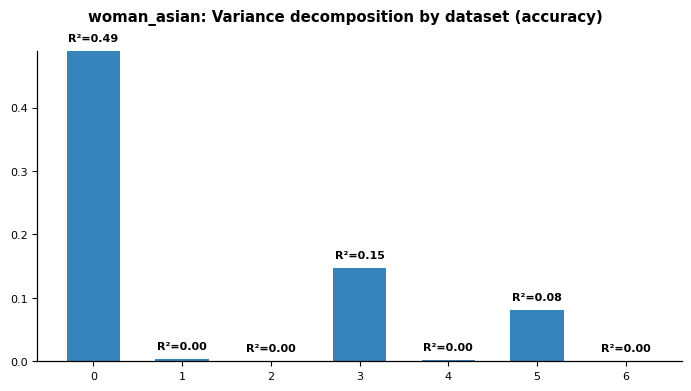

In [ ]:
from profiles.profile_sets import PersonSet
from cases.cases_config import CaseConfig
from plot_tools import apply_neurips_figure_style, new_pub_fig, bootstrap_line_ci
from analysis_3 import predictive_attribution_modeling

def variance_decomposition_across_sets(
    merged_dfs,
    dataset_labels,
    person_set: PersonSet,
    case: CaseConfig,
    *,
    outcome: str = "accuracy",
    group_keys: tuple | None = None,
    thename: str = "strategy",
    plots_root: str = "results/final_figs",
    stage: str = "tier3",
    fmt: str = "pdf",
    dpi: int | None = 200,
    sub_case: str | None = None,
):
    """
    For each dataset: run predictive_attribution_modeling and collect
    demo_unique, other_unique, shared, r2_full for the chosen outcome.
    Produces a single stacked bar chart saved under the resolved tier3 dir
    with strategy=thename.
    """
    from matplotlib import pyplot as plt
    import numpy as np

    apply_neurips_figure_style()

    assert len(merged_dfs) == len(dataset_labels), "merged_dfs and dataset_labels must match length"

    # Collect contributions per dataset
    rows = []
    for df, lab in zip(merged_dfs, dataset_labels):
        res = predictive_attribution_modeling(
            df,
            person_set=person_set,
            case=case,
            group_keys=group_keys,
            cv_lmg=True,    # keep consistent with your tier-3 default
        )
        par = res.get("predictive_association_results", {})
        got = par.get(outcome, {})
        if not got:
            # graceful fallback if that outcome wasn't modeled
            # (common alternates you might want)
            for alt in ("accuracy", "disagreement_rate", "extra_error_rate", "COI"):
                if par.get(alt, {}):
                    got = par[alt]; outcome = alt; break

        demo_u  = float(got.get("demo_unique", 0.0))
        other_u = float(got.get("other_unique", 0.0))
        shared  = float(got.get("shared_variance", 0.0))
        r2_full = float(got.get("r2_full", 0.0))

        # (optional) CIs if present – used for faint error whiskers on uniques
        ci = got.get("shapley_bootstrap_ci", {})
        demo_ci  = ci.get("demo_unique",  [np.nan, np.nan])
        other_ci = ci.get("other_unique", [np.nan, np.nan])

        rows.append({
            "label": lab,
            "demo_unique":  demo_u,
            "other_unique": other_u,
            "shared":       shared,
            "r2_full":      r2_full,
            "demo_lo": float(demo_ci[0]) if len(demo_ci)==2 else np.nan,
            "demo_hi": float(demo_ci[1]) if len(demo_ci)==2 else np.nan,
            "other_lo": float(other_ci[0]) if len(other_ci)==2 else np.nan,
            "other_hi": float(other_ci[1]) if len(other_ci)==2 else np.nan,
        })

    # Build the plot
    labels = [r["label"] for r in rows]
    demo   = np.array([r["demo_unique"]  for r in rows], float)
    other  = np.array([r["other_unique"] for r in rows], float)
    shared = np.array([r["shared"]       for r in rows], float)
    r2full = np.array([r["r2_full"]      for r in rows], float)

    x = np.arange(len(labels))
    width = 0.6

    title = f"{thename}: Variance decomposition by dataset ({outcome.replace('_',' ')})"
    fig, ax = new_pub_fig(title, figsize=(6.8, 3.8))

    b1 = ax.bar(x, demo,  width, label="Demographics (unique)",  alpha=0.90)
    b2 = ax.bar(x, other, width, bottom=demo, label="Other traits (unique)", alpha=0.90)
    b3 = ax.bar(x, shared,width, bottom=demo+other, label="Shared", alpha=0.90)

    # annotate R^2 full above each stack
    for i, r2 in enumerate(r2full):
        ax.text(i, demo[i]+other[i]+shared[i] + 0.012, f"R^2={r2:.2f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")

    # optional: faint whiskers for unique parts if CIs exist
    demo_lo = np.array([r["demo_lo"] for r in rows], float)
    demo_hi = np.array([r["demo_hi"] for r in rows], float)
    other_lo = np.array([r["other_lo"] for r in rows], float)
    other_hi = np.array([r["other_hi"] for r in rows], float)

    def _err(ax, y, lo, hi, bottom=0.0, offset=0.0):
        m = np.isfinite(lo) & np.isfinite(hi)
        if m.any():
            central = y[m] + bottom if np.isscalar(bottom) else y[m] + bottom[m]
            ax.errorbar(x[m] + offset, central,
                        yerr=[central - lo[m], hi[m] - central],
                        fmt="none", ecolor="k", elinewidth=0.8, capsize=2, alpha=0.35)

    _err(ax, demo, demo_lo, demo_hi, bottom=0.0, offset=-0.12)
    _err(ax, other, other_lo, other_hi, bottom=demo, offset=+0.12)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=25, ha="right")
    ax.set_ylabel("Variance explained (R^2)")
    ax.set_ylim(0, max(0.02, float(np.nanmax(demo+other+shared)) + 0.08))
    ax.legend(frameon=False, ncol=3)
    ax.grid(True, axis="y", alpha=0.3)

    # Save alongside your tier-3 outputs, using `thename` as the "strategy"
    path = _save(
        fig, case, plots_root=plots_root, strategy=thename, stage=stage,
        subdir="predictive", filename=f"variance_decomposition_{outcome}", fmt=fmt, dpi=dpi, sub_case=sub_case
    )
    print(f"[saved] {path}")
    return {"fig": fig, "path": path, "table": rows}

def _err(ax, y, lo, hi, bottom=0.0, offset=0.0):
    """
    Draw asymmetric CI whiskers for a stacked segment with height y and base `bottom`.
    `lo`/`hi` are absolute CIs for the segment (not the stack).
    Ensures non-negative yerr and corrects swapped bounds.
    """
    y = np.asarray(y, float)
    lo = np.asarray(lo, float)
    hi = np.asarray(hi, float)

    # finite mask
    m = np.isfinite(y) & np.isfinite(lo) & np.isfinite(hi)
    if not m.any():
        return

    # ensure lo <= hi
    lo_m = lo[m].copy()
    hi_m = hi[m].copy()
    swap = lo_m > hi_m
    if np.any(swap):
        lo_m[swap], hi_m[swap] = hi_m[swap], lo_m[swap]

    # scalar/vector bottom support
    if np.isscalar(bottom):
        bottom_m = np.full_like(y[m], float(bottom))
    else:
        bottom_m = np.asarray(bottom, float)[m]

    # central is at bottom + y; CI bounds are (bottom + lo/hi)
    central = bottom_m + y[m]
    lo_abs = bottom_m + lo_m
    hi_abs = bottom_m + hi_m

    # non-negative yerr
    low_err = np.maximum(0.0, central - lo_abs)
    high_err = np.maximum(0.0, hi_abs - central)
    yerr = np.vstack([low_err, high_err])

    ax.errorbar(
        x[m] + offset, central,
        yerr=yerr, fmt="none",
        ecolor="k", elinewidth=0.8, capsize=2, alpha=0.35
    )




merged_dfs = [merged_df_zs, merged_df_zs_mentalmanip, merged_df_zs_mmlu, merged_df_zs_mmlu_full, merged_df_zs_mmlu_full_control, merged_df_zs_mmlu_full_normative, merged_df_zs_mmlu_control]
labels     = ["Set1","Set2","Set3","Set4","Set5","Set6","Set7"]

out = variance_decomposition_across_sets(
    merged_dfs,
    labels,
    person_set=PERSON_ETHNICS,          # or your specific PersonSet
    case=stereotypes_case,              # your CaseConfig
    outcome="accuracy",                 # or "disagreement_rate", "extra_error_rate", "COI", ...
    group_keys=("gender","ethnicity"),  # or None to auto
    thename="woman_asian",              # ← will show on the plot and save path
    plots_root="results/final_figs"
)

In [6]:
"""
Publication-grade figure generation for Study 3
Separate plots for thesis - comparing MGSD, MentalManip, MMLU-Large, and MMLU
"""

import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import seaborn as sns

# Set publication-ready defaults
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'sans-serif',
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.linewidth': 0.8,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Color palette for consistency
COLORS = {
    'primary': '#2E86AB',
    'secondary': '#A23B72',
    'tertiary': '#F18F01',
    'quaternary': '#C73E1D',
    'light_gray': '#E8E8E8',
    'dark_gray': '#404040',
    'medium_gray': '#808080',
}

# Dataset order for all plots (4 datasets only)
DATASETS = ["MGSD", "MentalManip", "MMLU-Large", "MMLU"]
DATASET_COLORS = [COLORS['primary'], COLORS['secondary'], COLORS['tertiary'], COLORS['quaternary']]

OUTPUT_DIR = Path("figs")
OUTPUT_DIR.mkdir(exist_ok=True)

# ========== Updated Data with correct MMLU-Large values ==========
corr_vol_bold = {
    "MGSD": (-0.301, 0.019),
    "MentalManip": (-0.063, 0.632),
    "MMLU-Large": (-0.316, 0.014),  # Updated from new data
    "MMLU": (-0.050, 0.705),  # This was previously listed as MMLU-Large
}

corr_bold_acc = {
    "MGSD": (0.217, 0.097),
    "MentalManip": (-0.282, 0.029),
    "MMLU-Large": (0.528, 0.0001),  # Updated from new data
    "MMLU": (-0.161, 0.220),  # This was previously listed as MMLU-Large
}

rescue_summary = {
    "MGSD": {"inc": 0.119, "con": 0.126, "delta": -0.006, "p": 0.236},
    "MentalManip": {"inc": 0.135, "con": 0.134, "delta": 0.001, "p": 0.878},
    "MMLU-Large": {"inc": 0.234, "con": 0.219, "delta": 0.015, "p": 0.035},  # Updated from new data
    "MMLU": {"inc": 0.178, "con": 0.180, "delta": -0.002, "p": 0.650},  # This was previously listed as MMLU-Large
}

# Variance decomposition (Demographics, Other traits)
variance_decomp = {
    "MGSD": {
        "COI": (0.180, 0.191),
        "ATI": (0.262, 0.313),
        "CAI": (0.282, 0.339),
        "ACCURACY": (0.439, 0.037),
    },
    "MentalManip": {
        "COI": (0.108, 0.066),
        "ATI": (0.196, 0.089),
        "CAI": (0.122, 0.165),
        "ACCURACY": (0.103, 0.063),
    },
    "MMLU-Large": {  # Updated from new data
        "COI": (0.230, 0.046),
        "ATI": (0.510, 0.024),
        "CAI": (0.496, 0.029),
        "ACCURACY": (0.241, 0.041),
    },
    "MMLU": {  # This was previously listed as MMLU-Large
        "COI": (0.143, 0.014),
        "ATI": (0.076, 0.062),
        "CAI": (0.168, 0.075),
        "ACCURACY": (0.260, 0.072),
    },
}

# CV performance (for selected metrics)
cv_performance = {
    "MGSD": {"ATI": 0.281, "CAI": 0.334},
    "MentalManip": {"ATI": 0.078, "CAI": 0.048},
    "MMLU-Large": {"ATI": 0.175, "CAI": 0.164},  # Updated from new data
    "MMLU": {"ATI": 0.000, "CAI": 0.026},  # This was previously listed as MMLU-Large
}

# ========== FIGURE 1: Volatility vs Boldness Correlation ==========
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(DATASETS))
corr_vals = [corr_vol_bold[d][0] for d in DATASETS]
p_vals = [corr_vol_bold[d][1] for d in DATASETS]

# Color bars based on significance
bar_colors = [DATASET_COLORS[i] if p_vals[i] < 0.05 else COLORS['light_gray'] 
              for i in range(len(DATASETS))]
bars = ax.bar(x_pos, corr_vals, color=bar_colors, alpha=0.8, edgecolor='black', linewidth=1.2)

ax.axhline(0, color='black', linewidth=0.5, linestyle='-', alpha=0.3)
ax.set_ylabel('Correlation coefficient (r)', fontsize=12)
ax.set_title('Consistency-Boldness Relationship', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(DATASETS, fontsize=11)
ax.set_ylim(-0.4, 0.1)
ax.grid(axis='y', alpha=0.2, linestyle='--')

# Add values on bars
for i, (val, p, bar) in enumerate(zip(corr_vals, p_vals, bars)):
    height = bar.get_height()
    y_pos = height - 0.02 if height < 0 else height + 0.01
    color = 'black' if p < 0.05 else COLORS['medium_gray']
    ax.text(bar.get_x() + bar.get_width()/2, y_pos, f'{val:.3f}',
             ha='center', va='top' if height < 0 else 'bottom', 
             fontsize=10, color=color, fontweight='bold' if p < 0.05 else 'normal')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig1_volatility_boldness.pdf", bbox_inches='tight', dpi=300)
plt.close()

# ========== FIGURE 2: Boldness vs Accuracy Correlation ==========
fig, ax = plt.subplots(figsize=(8, 5))
corr_vals = [corr_bold_acc[d][0] for d in DATASETS]
p_vals = [corr_bold_acc[d][1] for d in DATASETS]

bar_colors = [DATASET_COLORS[i] if p_vals[i] < 0.05 else COLORS['light_gray'] 
              for i in range(len(DATASETS))]
bars = ax.bar(x_pos, corr_vals, color=bar_colors, alpha=0.8, edgecolor='black', linewidth=1.2)

ax.axhline(0, color='black', linewidth=0.5, linestyle='-', alpha=0.3)
ax.set_ylabel('Correlation coefficient (r)', fontsize=12)
ax.set_title('Boldness-Accuracy Relationship', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(DATASETS, fontsize=11)
ax.set_ylim(-0.4, 0.6)
ax.grid(axis='y', alpha=0.2, linestyle='--')

for i, (val, p, bar) in enumerate(zip(corr_vals, p_vals, bars)):
    height = bar.get_height()
    y_pos = height + 0.02 if height > 0 else height - 0.02
    color = 'black' if p < 0.05 else COLORS['medium_gray']
    ax.text(bar.get_x() + bar.get_width()/2, y_pos, f'{val:.3f}',
             ha='center', va='bottom' if height > 0 else 'top', 
             fontsize=10, color=color, fontweight='bold' if p < 0.05 else 'normal')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig2_boldness_accuracy.pdf", bbox_inches='tight', dpi=300)
plt.close()

# ========== FIGURE 3: Error Correction Rates Comparison ==========
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(DATASETS))
width = 0.35
inc_rates = [rescue_summary[d]["inc"] for d in DATASETS]
con_rates = [rescue_summary[d]["con"] for d in DATASETS]

bars1 = ax.bar(x_pos - width/2, inc_rates, width, label='Inconsistent', 
                color=COLORS['secondary'], alpha=0.8, edgecolor='black')
bars2 = ax.bar(x_pos + width/2, con_rates, width, label='Consistent', 
                color=COLORS['primary'], alpha=0.8, edgecolor='black')

ax.set_ylabel('Error Correction Rate', fontsize=12)
ax.set_title('Error Correction Rates by Consistency Type', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(DATASETS, fontsize=11)
ax.legend(frameon=False, loc='upper right')
ax.set_ylim(0, 0.28)
ax.grid(axis='y', alpha=0.2, linestyle='--')

# Add significance indicators with connecting lines
for i, d in enumerate(DATASETS):
    p_val = rescue_summary[d]["p"]
    if p_val < 0.05:
        max_height = max(inc_rates[i], con_rates[i])
        ax.plot([i-width/2, i+width/2], [max_height+0.01, max_height+0.01], 
                'k-', linewidth=1.5)
        ax.text(i, max_height+0.02, 'p < 0.05', ha='center', va='bottom', 
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig3_error_correction_rates.pdf", bbox_inches='tight', dpi=300)
plt.close()

# ========== FIGURE 4: Error Correction Effect Sizes ==========
fig, ax = plt.subplots(figsize=(8, 5))
deltas = [rescue_summary[d]["delta"] for d in DATASETS]
p_vals = [rescue_summary[d]["p"] for d in DATASETS]
colors = [COLORS['quaternary'] if p < 0.05 else COLORS['light_gray'] for p in p_vals]

bars = ax.bar(x_pos, deltas, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_ylabel('Difference in Error Correction Rate\n(Inconsistent - Consistent)', fontsize=12)
ax.set_title('Effect Size of Consistency on Error Correction', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(DATASETS, fontsize=11)
ax.set_ylim(-0.02, 0.02)
ax.grid(axis='y', alpha=0.2, linestyle='--')

# Add values
for i, (delta, p) in enumerate(zip(deltas, p_vals)):
    y_pos = delta + 0.001 if delta > 0 else delta - 0.001
    color = 'black' if p < 0.05 else COLORS['medium_gray']
    ax.text(i, y_pos, f'{delta:.3f}', ha='center', 
             va='bottom' if delta > 0 else 'top', 
             fontsize=10, color=color, fontweight='bold' if p < 0.05 else 'normal')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig4_error_correction_deltas.pdf", bbox_inches='tight', dpi=300)
plt.close()

# ========== FIGURE 5: COI Variance Decomposition ==========
fig, ax = plt.subplots(figsize=(8, 5))
demo_vals = [variance_decomp[d]["COI"][0] for d in DATASETS]
other_vals = [variance_decomp[d]["COI"][1] for d in DATASETS]

x = np.arange(len(DATASETS))
width = 0.35

bars1 = ax.bar(x - width/2, demo_vals, width, label='Demographics',
               color=COLORS['primary'], alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, other_vals, width, label='Other traits',
               color=COLORS['tertiary'], alpha=0.8, edgecolor='black')

ax.set_ylabel('In-sample R²', fontsize=12)
ax.set_title('COI Variance Decomposition', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(DATASETS, fontsize=11)
ax.set_ylim(0, 0.3)
ax.legend(frameon=False, loc='upper right')
ax.grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig5_coi_variance.pdf", bbox_inches='tight', dpi=300)
plt.close()

# ========== FIGURE 6: ATI Variance Decomposition ==========
fig, ax = plt.subplots(figsize=(8, 5))
demo_vals = [variance_decomp[d]["ATI"][0] for d in DATASETS]
other_vals = [variance_decomp[d]["ATI"][1] for d in DATASETS]

bars1 = ax.bar(x - width/2, demo_vals, width, label='Demographics',
               color=COLORS['primary'], alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, other_vals, width, label='Other traits',
               color=COLORS['tertiary'], alpha=0.8, edgecolor='black')

ax.set_ylabel('In-sample R²', fontsize=12)
ax.set_title('ATI Variance Decomposition', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(DATASETS, fontsize=11)
ax.set_ylim(0, 0.6)
ax.legend(frameon=False, loc='upper right')
ax.grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig6_ati_variance.pdf", bbox_inches='tight', dpi=300)
plt.close()

# ========== FIGURE 7: CAI Variance Decomposition ==========
fig, ax = plt.subplots(figsize=(8, 5))
demo_vals = [variance_decomp[d]["CAI"][0] for d in DATASETS]
other_vals = [variance_decomp[d]["CAI"][1] for d in DATASETS]

bars1 = ax.bar(x - width/2, demo_vals, width, label='Demographics',
               color=COLORS['primary'], alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, other_vals, width, label='Other traits',
               color=COLORS['tertiary'], alpha=0.8, edgecolor='black')

ax.set_ylabel('In-sample R²', fontsize=12)
ax.set_title('CAI Variance Decomposition', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(DATASETS, fontsize=11)
ax.set_ylim(0, 0.6)
ax.legend(frameon=False, loc='upper right')
ax.grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig7_cai_variance.pdf", bbox_inches='tight', dpi=300)
plt.close()

# ========== FIGURE 8: Accuracy Variance Decomposition ==========
fig, ax = plt.subplots(figsize=(8, 5))
demo_vals = [variance_decomp[d]["ACCURACY"][0] for d in DATASETS]
other_vals = [variance_decomp[d]["ACCURACY"][1] for d in DATASETS]

bars1 = ax.bar(x - width/2, demo_vals, width, label='Demographics',
               color=COLORS['primary'], alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, other_vals, width, label='Other traits',
               color=COLORS['tertiary'], alpha=0.8, edgecolor='black')

ax.set_ylabel('In-sample R²', fontsize=12)
ax.set_title('Accuracy Prediction Variance Decomposition', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(DATASETS, fontsize=11)
ax.set_ylim(0, 0.5)
ax.legend(frameon=False, loc='upper right')
ax.grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig8_accuracy_variance.pdf", bbox_inches='tight', dpi=300)
plt.close()

# ========== FIGURE 9: ATI Cross-Validation Performance ==========
fig, ax = plt.subplots(figsize=(8, 5))
in_sample = [variance_decomp[d]["ATI"][0] + variance_decomp[d]["ATI"][1] for d in DATASETS]
cv_vals = [cv_performance[d]["ATI"] for d in DATASETS]

bars1 = ax.bar(x - width/2, in_sample, width, label='In-sample',
               color=COLORS['dark_gray'], alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, cv_vals, width, label='Cross-validated',
               color=COLORS['quaternary'], alpha=0.8, edgecolor='black')

ax.set_ylabel('R²', fontsize=12)
ax.set_title('ATI Cross-Validation Performance', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(DATASETS, fontsize=11)
ax.set_ylim(-0.1, 0.65)
ax.axhline(0, color='black', linewidth=0.5, linestyle='-', alpha=0.3)
ax.legend(frameon=False, loc='upper right')
ax.grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig9_ati_cv_performance.pdf", bbox_inches='tight', dpi=300)
plt.close()

# ========== FIGURE 10: CAI Cross-Validation Performance ==========
fig, ax = plt.subplots(figsize=(8, 5))
in_sample = [variance_decomp[d]["CAI"][0] + variance_decomp[d]["CAI"][1] for d in DATASETS]
cv_vals = [cv_performance[d]["CAI"] for d in DATASETS]

bars1 = ax.bar(x - width/2, in_sample, width, label='In-sample',
               color=COLORS['dark_gray'], alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, cv_vals, width, label='Cross-validated',
               color=COLORS['quaternary'], alpha=0.8, edgecolor='black')

ax.set_ylabel('R^2', fontsize=12)
ax.set_title('CAI Cross-Validation Performance', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(DATASETS, fontsize=11)
ax.set_ylim(-0.1, 0.7)
ax.axhline(0, color='black', linewidth=0.5, linestyle='-', alpha=0.3)
ax.legend(frameon=False, loc='upper right')
ax.grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig10_cai_cv_performance.pdf", bbox_inches='tight', dpi=300)
plt.close()

# ========== FIGURE 11: Summary Heatmap ==========
fig, ax = plt.subplots(figsize=(10, 7))

# Create summary matrix
summary_metrics = {
    'Volatility-Boldness r': [corr_vol_bold[d][0] for d in DATASETS],
    'Boldness-Accuracy r': [corr_bold_acc[d][0] for d in DATASETS],
    'Error Correction Difference': [rescue_summary[d]["delta"] for d in DATASETS],
    'Demo R^2 (COI)': [variance_decomp[d]["COI"][0] for d in DATASETS],
    'Demo R^2 (ATI)': [variance_decomp[d]["ATI"][0] for d in DATASETS],
    'Demo R^2 (CAI)': [variance_decomp[d]["CAI"][0] for d in DATASETS],
    'CV R^2 (ATI)': [cv_performance[d]["ATI"] for d in DATASETS],
    'CV R^2 (CAI)': [cv_performance[d]["CAI"] for d in DATASETS],
}

# Create matrix
matrix = np.array(list(summary_metrics.values()))

# Create custom colormap
from matplotlib.colors import LinearSegmentedColormap
colors_list = [(0.2, 0.4, 0.8), (1, 1, 1), (0.8, 0.2, 0.2)]
n_bins = 100
cmap = LinearSegmentedColormap.from_list('custom', colors_list, N=n_bins)

im = ax.imshow(matrix, cmap=cmap, aspect='auto', vmin=-0.5, vmax=0.5)

# Set ticks and labels
ax.set_xticks(np.arange(len(DATASETS)))
ax.set_yticks(np.arange(len(summary_metrics)))
ax.set_xticklabels(DATASETS, fontsize=11)
ax.set_yticklabels(list(summary_metrics.keys()), fontsize=10)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Value', rotation=270, labelpad=15)

# Add text annotations and significance indicators
for i in range(len(summary_metrics)):
    for j in range(len(DATASETS)):
        value = matrix[i, j]
        
        # Determine if this cell should be highlighted for significance
        is_significant = False
        if i == 0:  # Volatility-boldness
            is_significant = corr_vol_bold[DATASETS[j]][1] < 0.05
        elif i == 1:  # Boldness-accuracy
            is_significant = corr_bold_acc[DATASETS[j]][1] < 0.05
        elif i == 2:  # Error correction
            is_significant = rescue_summary[DATASETS[j]]["p"] < 0.05
        
        # Add text
        text_color = "white" if abs(value) > 0.3 else "black"
        fontweight = 'bold' if is_significant else 'normal'
        text = ax.text(j, i, f'{value:.3f}',
                      ha="center", va="center", color=text_color,
                      fontsize=9, fontweight=fontweight)
        
        # Add border for significant values
        if is_significant:
            rect = Rectangle((j-0.45, i-0.45), 0.9, 0.9,
                           fill=False, edgecolor='black', linewidth=2.5)
            ax.add_patch(rect)

ax.set_title('Summary of Key Metrics Across Datasets', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Dataset', fontsize=12)
ax.set_ylabel('Metric', fontsize=12)

# Add legend for significance
legend_elements = [mpatches.Rectangle((0, 0), 1, 1, fill=False, 
                                     edgecolor='black', linewidth=2.5, 
                                     label='p < 0.05')]
ax.legend(handles=legend_elements, loc='upper left', 
         bbox_to_anchor=(1.15, 1), frameon=False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig11_summary_heatmap.pdf", bbox_inches='tight', dpi=300)
plt.close()

print(f"✓ Generated 11 separate publication-grade figures in {OUTPUT_DIR}/")
print("\nFigures created:")
print("1. fig1_volatility_boldness.pdf - Consistency-boldness correlations")
print("2. fig2_boldness_accuracy.pdf - Boldness-accuracy correlations")
print("3. fig3_error_correction_rates.pdf - Error correction rates comparison")
print("4. fig4_error_correction_deltas.pdf - Error correction effect sizes")
print("5. fig5_coi_variance.pdf - COI variance decomposition")
print("6. fig6_ati_variance.pdf - ATI variance decomposition")
print("7. fig7_cai_variance.pdf - CAI variance decomposition")
print("8. fig8_accuracy_variance.pdf - Accuracy variance decomposition")
print("9. fig9_ati_cv_performance.pdf - ATI cross-validation performance")
print("10. fig10_cai_cv_performance.pdf - CAI cross-validation performance")
print("11. fig11_summary_heatmap.pdf - Comprehensive summary heatmap")

✓ Generated 11 separate publication-grade figures in figs/

Figures created:
1. fig1_volatility_boldness.pdf - Consistency-boldness correlations
2. fig2_boldness_accuracy.pdf - Boldness-accuracy correlations
3. fig3_error_correction_rates.pdf - Error correction rates comparison
4. fig4_error_correction_deltas.pdf - Error correction effect sizes
5. fig5_coi_variance.pdf - COI variance decomposition
6. fig6_ati_variance.pdf - ATI variance decomposition
7. fig7_cai_variance.pdf - CAI variance decomposition
8. fig8_accuracy_variance.pdf - Accuracy variance decomposition
9. fig9_ati_cv_performance.pdf - ATI cross-validation performance
10. fig10_cai_cv_performance.pdf - CAI cross-validation performance
11. fig11_summary_heatmap.pdf - Comprehensive summary heatmap
